In [2]:
import pandas as pd
import glob 
import numpy as np
import protfasta
from ete4 import Tree
from ete4.treeview import TreeStyle, TextFace, NodeStyle


In [3]:
interpro = pd.read_csv("../data/interpro_tf_doms_7-22-25.csv")
interpro["Interpro superfamily domain code"] = interpro["Interpro superfamily domain code"].str.strip().fillna(interpro["Interpro domain code"])
interpro

,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,Interpro superfamily domain code
0,C2H2 ZF(non-KRAB),Zinc finger C2H2-type,IPR013087,Zinc finger C2H2 superfamily,IPR036236
1,C2H2 ZF(KRAB),Zinc finger C2H2-type,IPR013087,Zinc finger C2H2 superfamily,IPR036236
2,Homeodomain,Homeodomain,IPR001356,Homedomain-like superfamily,IPR009057
3,bHLH,"Myc-type, basic helix-loop-helix (bHLH) domain",IPR011598,Helix-loop-helix DNA-binding domain superfamily,IPR036638
4,bZIP,Basic-leucine zipper domain,IPR004827,Basic-leucine zipper domain superfamily,IPR046347
5,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,IPR036388
6,Nuclear receptor,"Nuclear hormone receptor, ligand-binding domain",IPR000536,Nuclear hormone receptor-like domain superfamily,IPR035500
7,HMG/Sox,High mobility group box domain,IPR009071,High mobility group box domain superfamily,IPR036910
8,Ets,Ets domain,IPR000418,Winged helix-like DNA-binding domain superfamily,IPR036388
9,T-box,"T-box transcription factor, DNA-binding domain",IPR046360,T-box superfamily,IPR036960


In [4]:
all_dfs = []

for path in glob.glob("../data/interpro_uniprot_downloads/IPR*"):
    fasta_dict = protfasta.read_fasta(path, invalid_sequence_action = 'remove')
    path_df = pd.DataFrame({"path" : path, "id" : fasta_dict.keys(), "seq" : fasta_dict.values(), "evidence" : "protein"})
    all_dfs.append(path_df)

for path in glob.glob("../data/interpro_uniprot_downloads/transcript_evidence/*"):
    fasta_dict = protfasta.read_fasta(path, invalid_sequence_action = 'remove')
    path_df = pd.DataFrame({"path" : path, "id" : fasta_dict.keys(), "seq" : fasta_dict.values(), "evidence" : "transcript"})
    all_dfs.append(path_df)

all_dfs = pd.concat(all_dfs)
all_dfs["Interpro superfamily domain code"] = all_dfs["path"].str.split("/").str[-1].str.split(".").str[0]
# Drop dups 
all_dfs = all_dfs.drop_duplicates(subset = "seq")
all_dfs["len"] = all_dfs["seq"].str.len()
all_dfs = all_dfs[all_dfs["len"] >= 53]
all_dfs = all_dfs[all_dfs["len"] <= 1891]
all_dfs

,path,id,seq,evidence,Interpro superfamily domain code,len
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610
...,...,...,...,...,...,...
5736,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300
5737,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939
5738,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294
5739,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329


In [128]:
# Keep rows with desired codes
seqs_with_codes = pd.merge(all_dfs, interpro, on = "Interpro superfamily domain code")
seqs_with_codes["name"] = seqs_with_codes["id"].str.split("|").str[2]
seqs_with_codes["Interpro domain name shortened"] = seqs_with_codes["Interpro domain name"].str.replace(" domain", "")
seqs_with_codes = seqs_with_codes.drop_duplicates(subset = "seq")
seqs_with_codes["uniprotID"] = seqs_with_codes["id"].str.split("|").str[1]
seqs_with_codes

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
334932,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846
334933,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25
334934,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6
334935,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7


In [129]:
seqs_with_codes["species"] = seqs_with_codes["name"].str.extract(r'OS=(.*) OX')
seqs_with_codes["species"] = seqs_with_codes["species"].str.split(r" \(").str[0]
seqs_with_codes["species"] = seqs_with_codes["species"].str.split(" serotype").str[0]
seqs_with_codes["species"] = seqs_with_codes["species"].str.split(" serovar").str[0]
seqs_with_codes["species"] = seqs_with_codes["species"].str.split(r" sp$").str[0]
seqs_with_codes

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8,Drosophila melanogaster
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6,Drosophila melanogaster
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5,Caenorhabditis elegans
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44,Homo sapiens
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87,Drosophila melanogaster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334932,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846,Ceratitis capitata
334933,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25,Ceratitis capitata
334934,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6,Mimachlamys nobilis
334935,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7,Tisochrysis lutea


In [130]:
seqs_with_codes[["species"]].drop_duplicates().to_csv("../data/input_data_species_redone.txt", index=False, header=False)

In [131]:
# interpro_species = pd.read_csv("../data/interpro_seq_species.txt", sep = "\t")
# interpro_species = interpro_species.rename(columns = {"From" : "uniprotID"})
# interpro_species = interpro_species.drop(columns = "Entry")
# interpro_species = interpro_species[interpro_species["uniprotID"].isin(seqs_with_codes["uniprotID"])]
# interpro_species["Organism"] = interpro_species["Organism"].str.split(" \(").str[0]
# interpro_species["Organism"] = interpro_species["Organism"].str.split(" serotype").str[0]
# interpro_species["Organism"] = interpro_species["Organism"].str.split(" serovar").str[0]
# interpro_species

In [132]:
# interpro_species[["Organism"]].to_csv("../data/input_data_species.txt", index=False, header=False)

In [133]:
def levels_from_root(node):
    if node.is_root: 
        return 0
    else:
        return 1 + levels_from_root(node.up)

In [134]:
def total_children(node):
    if len(node.children) == 0:
        return 0
    else:
        return len(node.children) + sum([total_children(child) for child in node.children])

In [135]:
seqs_with_codes

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8,Drosophila melanogaster
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6,Drosophila melanogaster
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5,Caenorhabditis elegans
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44,Homo sapiens
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87,Drosophila melanogaster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334932,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846,Ceratitis capitata
334933,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25,Ceratitis capitata
334934,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6,Mimachlamys nobilis
334935,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7,Tisochrysis lutea


In [136]:
seqs_with_codes[seqs_with_codes["species"] == "Homo sapiens"]

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44,Homo sapiens
14,../data/interpro_uniprot_downloads/IPR037095.f...,sp|Q06330|SUH_HUMAN Recombining binding protei...,MDHTEGSPAEEPPAHAPSPGKFGERPPPKRLTREAMRNYLKERGDQ...,protein,IPR037095,500,CSL,"RBP-J/Cbf11/Cbf12, DNA binding",IPR015351,"RBP-J/Cbf11, DNA binding domain superfamily",SUH_HUMAN Recombining binding protein suppress...,"RBP-J/Cbf11/Cbf12, DNA binding",Q06330,Homo sapiens
17,../data/interpro_uniprot_downloads/IPR037095.f...,sp|Q9UBG7|RBPJL_HUMAN Recombining binding prot...,MDPAGAADPSVPPNPLTHLSLQDRSEMQLQSEADRRSLPGTWTRSS...,protein,IPR037095,517,CSL,"RBP-J/Cbf11/Cbf12, DNA binding",IPR015351,"RBP-J/Cbf11, DNA binding domain superfamily",RBPJL_HUMAN Recombining binding protein suppre...,"RBP-J/Cbf11/Cbf12, DNA binding",Q9UBG7,Homo sapiens
19,../data/interpro_uniprot_downloads/IPR037095.f...,tr|A0A7P0T947|A0A7P0T947_HUMAN Recombining bin...,MRNYLKERGDQTVLILHAKVAQKSYGNEKRFFCPPPCVYLMGSGWK...,protein,IPR037095,463,CSL,"RBP-J/Cbf11/Cbf12, DNA binding",IPR015351,"RBP-J/Cbf11, DNA binding domain superfamily",A0A7P0T947_HUMAN Recombining binding protein s...,"RBP-J/Cbf11/Cbf12, DNA binding",A0A7P0T947,Homo sapiens
20,../data/interpro_uniprot_downloads/IPR037095.f...,tr|A0A7P0T9Y9|A0A7P0T9Y9_HUMAN Recombining bin...,MRNYLKERGDQTVLILHAKVAQKSYGNEKRFFCPPPCVYLMGSGWK...,protein,IPR037095,457,CSL,"RBP-J/Cbf11/Cbf12, DNA binding",IPR015351,"RBP-J/Cbf11, DNA binding domain superfamily",A0A7P0T9Y9_HUMAN Recombining binding protein s...,"RBP-J/Cbf11/Cbf12, DNA binding",A0A7P0T9Y9,Homo sapiens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334668,../data/interpro_uniprot_downloads/transcript_...,tr|Q8NF60|Q8NF60_HUMAN FLJ00327 protein (Fragm...,RARPAAAWESLRTCPQTPAVPPIPPTLCRLVEEFMLLANMAVAHKI...,transcript,IPR012340,266,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",Q8NF60_HUMAN FLJ00327 protein (Fragment) OS=Ho...,Cold-shock,Q8NF60,Homo sapiens
334672,../data/interpro_uniprot_downloads/transcript_...,tr|Q8TEM7|Q8TEM7_HUMAN FLJ00166 protein (Fragm...,GNYQPVGLRALHSLAMDRDLLRQSLNCHGSSLLSLLRSEQQDNPHF...,transcript,IPR012340,454,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",Q8TEM7_HUMAN FLJ00166 protein (Fragment) OS=Ho...,Cold-shock,Q8TEM7,Homo sapiens
334687,../data/interpro_uniprot_downloads/transcript_...,tr|Q96GD7|Q96GD7_HUMAN CSDA protein OS=Homo sa...,MSEAGEATTTTTTTLPQAPTEAAAAAPQDPAPKSPVGSGAPQAAAP...,transcript,IPR012340,303,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",Q96GD7_HUMAN CSDA protein OS=Homo sapiens OX=9...,Cold-shock,Q96GD7,Homo sapiens
334689,../data/interpro_uniprot_downloads/transcript_...,tr|Q99540|Q99540_HUMAN DNA ligase (NAD(+)) OS=...,MLPEFTPIEQLSTSAAQQEVAQLQADLTEYGVAYYEQDAPLVEDHV...,transcript,IPR012340,454,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",Q99540_HUMAN DNA ligase (NAD(+)) OS=Homo sapie...,Cold-shock,Q99540,Homo sapiens


In [137]:
# Get all node names
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)

def return_node_names(node, name_list=None):
    if name_list is None:
        name_list = []
    
    name_list.append(node.name)  # include both internal and leaf nodes
    
    for child in node.children:
        return_node_names(child, name_list)
    
    return name_list

all_names = return_node_names(t)
len(all_names)

8966

In [138]:
for name in all_names:
    if "Zea" in name:
        print(name)

Zea
Zea nicaraguensis
Zea mays subsp. mays


In [139]:
seqs_with_codes[~seqs_with_codes["species"].isin(all_names)]#["species"].value_counts()[:30]

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species
16,../data/interpro_uniprot_downloads/IPR037095.f...,sp|Q91880|SUH_XENLA Suppressor of hairless pro...,MQPGIPKYTPSAIQLAPVVTGKFGERPQPKRLTREAMRNYLKERGD...,protein,IPR037095,501,CSL,"RBP-J/Cbf11/Cbf12, DNA binding",IPR015351,"RBP-J/Cbf11, DNA binding domain superfamily",SUH_XENLA Suppressor of hairless protein homol...,"RBP-J/Cbf11/Cbf12, DNA binding",Q91880,Xenopus laevis
55,../data/interpro_uniprot_downloads/IPR000967.f...,tr|A0A0P0WV74|A0A0P0WV74_ORYSJ Os06g0252300 pr...,VCVLQCHPGPCPPCKAFAPDRLCPCGKQTIVRRCADRTTPVTCGQR...,protein,IPR000967,847,NFX,"Zinc finger, NF-X1-type",IPR000967,NaN,A0A0P0WV74_ORYSJ Os06g0252300 protein (Fragmen...,"Zinc finger, NF-X1-type",A0A0P0WV74,Oryza sativa subsp. japonica
59,../data/interpro_uniprot_downloads/IPR000967.f...,tr|A0A804QIW2|A0A804QIW2_MAIZE RING-type domai...,MPSSYAAAAAGSSSRKPNRTSSAAAPTLRPPAPSPSPAPAPLAVNP...,protein,IPR000967,772,NFX,"Zinc finger, NF-X1-type",IPR000967,NaN,A0A804QIW2_MAIZE RING-type domain-containing p...,"Zinc finger, NF-X1-type",A0A804QIW2,Zea mays
60,../data/interpro_uniprot_downloads/IPR000967.f...,tr|A0A804QJU5|A0A804QJU5_MAIZE NF-X1-type doma...,MGKHIECTPGTPCPPCKEVVLVSCFGQHLGQERTMPCCKWRPFPCE...,protein,IPR000967,344,NFX,"Zinc finger, NF-X1-type",IPR000967,NaN,A0A804QJU5_MAIZE NF-X1-type domain-containing ...,"Zinc finger, NF-X1-type",A0A804QJU5,Zea mays
61,../data/interpro_uniprot_downloads/IPR000967.f...,tr|A0A804UB47|A0A804UB47_MAIZE RING-type domai...,MQPSTDRRRGGGPVVTASHVWRPRPAASAPGSILPLPTSASASASE...,protein,IPR000967,1101,NFX,"Zinc finger, NF-X1-type",IPR000967,NaN,A0A804UB47_MAIZE RING-type domain-containing p...,"Zinc finger, NF-X1-type",A0A804UB47,Zea mays
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334880,../data/interpro_uniprot_downloads/transcript_...,tr|V9IFQ2|V9IFQ2_APICE Y-box factor OS=Apis ce...,MADPEKQPEQPKAGQQKLIIANKVTGTVKWFNVKSGYGFINRNDTK...,transcript,IPR012340,258,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",V9IFQ2_APICE Y-box factor OS=Apis cerana OX=74...,Cold-shock,V9IFQ2,Apis cerana
334881,../data/interpro_uniprot_downloads/transcript_...,tr|V9IIV1|V9IIV1_APICE Small ribosomal subunit...,MADQSERAFQKQPTIFLNRKKGLGPKRRKPMRYSRNVGLGFKTPRE...,transcript,IPR012340,155,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",V9IIV1_APICE Small ribosomal subunit protein u...,Cold-shock,V9IIV1,Apis cerana
334882,../data/interpro_uniprot_downloads/transcript_...,tr|V9IKQ6|V9IKQ6_APICE Nucleolar protein OS=Ap...,MANCELNQIFLGEIASVQNYGAFIRIPGCSVQGLIHRSQISCVHVD...,transcript,IPR012340,183,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",V9IKQ6_APICE Nucleolar protein OS=Apis cerana ...,Cold-shock,V9IKQ6,Apis cerana
334883,../data/interpro_uniprot_downloads/transcript_...,tr|V9ILB5|V9ILB5_APICE Cold shock domain-conta...,MSRNEVTRFPFGTFTGMEGSTGYTEEPTTNNSTYQDQSENQGTRET...,transcript,IPR012340,697,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",V9ILB5_APICE Cold shock domain-containing prot...,Cold-shock,V9ILB5,Apis cerana


In [140]:
from rapidfuzz import process, fuzz

min_score = 100

uniprot = []
ncbi = []
scores = []

for name in seqs_with_codes["species"].drop_duplicates().dropna():
    match, score, _ = process.extractOne(name, all_names, scorer=fuzz.ratio)
    min_score = min(min_score, score)
    if score >= 85:  # threshold for confidence
        uniprot.append(name)
        ncbi.append(match)
        scores.append(score)


In [141]:
len(mapping) / len(seqs_with_codes["species"].drop_duplicates().dropna())

0.9678395160006369

In [142]:
mapping = pd.DataFrame({'uniprot' : uniprot, 'ncbi' : ncbi, 'scores' : scores})
mapping.sort_values(by = "scores")

,uniprot,ncbi,scores
16,Bacillus subtilis,Bacillus subtilis group,85.000000
152,Rhizobium meliloti,Sinorhizobium meliloti,85.000000
4182,Cyprinus carpio var. jian,Cyprinus carpio 'jian',85.106383
1794,Lymantria dispar multicapsid nuclear polyhedro...,Lymantria dispar multiple nucleopolyhedrovirus,85.148515
3001,Brassica rapa subsp. rapa,Brassica rapa subsp. oleifera,85.185185
...,...,...,...
2041,Cunninghamia lanceolata,Cunninghamia lanceolata,100.000000
2040,Jatropha curcas,Jatropha curcas,100.000000
2039,Sycon ciliatum,Sycon ciliatum,100.000000
2048,Euperipatoides rowelli,Euperipatoides rowelli,100.000000


In [143]:
seqs_with_codes = pd.merge(seqs_with_codes, mapping, left_on = "species", right_on="uniprot", how = 'left')
seqs_with_codes

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species,uniprot,ncbi,scores
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8,Drosophila melanogaster,Drosophila melanogaster,Drosophila melanogaster,100.0
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6,Drosophila melanogaster,Drosophila melanogaster,Drosophila melanogaster,100.0
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5,Caenorhabditis elegans,Caenorhabditis elegans,Caenorhabditis elegans,100.0
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44,Homo sapiens,Homo sapiens,Homo sapiens,100.0
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87,Drosophila melanogaster,Drosophila melanogaster,Drosophila melanogaster,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135201,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846,Ceratitis capitata,Ceratitis capitata,Ceratitis capitata,100.0
135202,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25,Ceratitis capitata,Ceratitis capitata,Ceratitis capitata,100.0
135203,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6,Mimachlamys nobilis,Mimachlamys nobilis,Mimachlamys nobilis,100.0
135204,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7,Tisochrysis lutea,Tisochrysis lutea,Tisochrysis lutea,100.0


In [150]:
total_children_cache = {}

def total_children_in_data(node):
    if node in total_children_cache:
        return total_children_cache[node]

    if len(node.children) == 0:
        result = len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
    else:
        result = (
            len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
            + sum([total_children_in_data(child) for child in node.children])
        )

    total_children_cache[node] = result
    return result


In [12]:
t = Tree(open("../data/training_data_phyliptree_more_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False

# Collapse nodes with more than 100 leaves
# for node in t.traverse():
#     if total_children(node) > 5:
#         node.remove_children()
#t.collapse(1)

# Optional: customize tree style to show collapsed nodes as triangles


# for node in t.traverse():
#     node_from_root = levels_from_root(node)
#     if node_from_root <= 3:
#         print(node.name)
#         size = 100 #min(500, 10 + node_from_root // 4)  # Cap size to 80
#         tf = TextFace(f"{node.name}", fsize=size)
#         tf.rotation = 0
#         node.add_face(tf, column=0, position="branch-right")
        # # Calculate angle of node (ete3 provides node._angle in circular mode)
        # if hasattr(node, "_angle"):
        #     angle = node._angle
        # else:
        #     # fallback if not precomputed
        #     continue

        # # Rotate text to match radial layout
        # tf.rotation = angle if angle < 180 else angle - 180
        # tf.rotation = (tf.rotation + 90) % 360  # Adjust for upright readability


t.render('%%inline', w=10, units='mm', tree_style=circular_style, dpi = 300)


FileNotFoundError: [Errno 2] No such file or directory: '../data/training_data_phyliptree_more_species.phy'

In [13]:
t = Tree(open("../data/training_data_phyliptree_more_species.phy"), parser = 1)

FileNotFoundError: [Errno 2] No such file or directory: '../data/training_data_phyliptree_more_species.phy'

In [14]:
children_dict = {}
levels_from_root_dict = {}
for node in t.traverse():
    children_dict[node.name] = total_children(node)
    levels_from_root_dict[node.name] = levels_from_root(node)

NameError: name 't' is not defined

In [15]:
node_sizes = pd.DataFrame({"node" : children_dict.keys(), 
                           "num_children" : children_dict.values(),
                           "levels_from_root" : levels_from_root_dict.values()})
node_sizes

,node,num_children,levels_from_root


In [16]:
keep_nodes = node_sizes[node_sizes["levels_from_root"] < 2]
keep_nodes

,node,num_children,levels_from_root


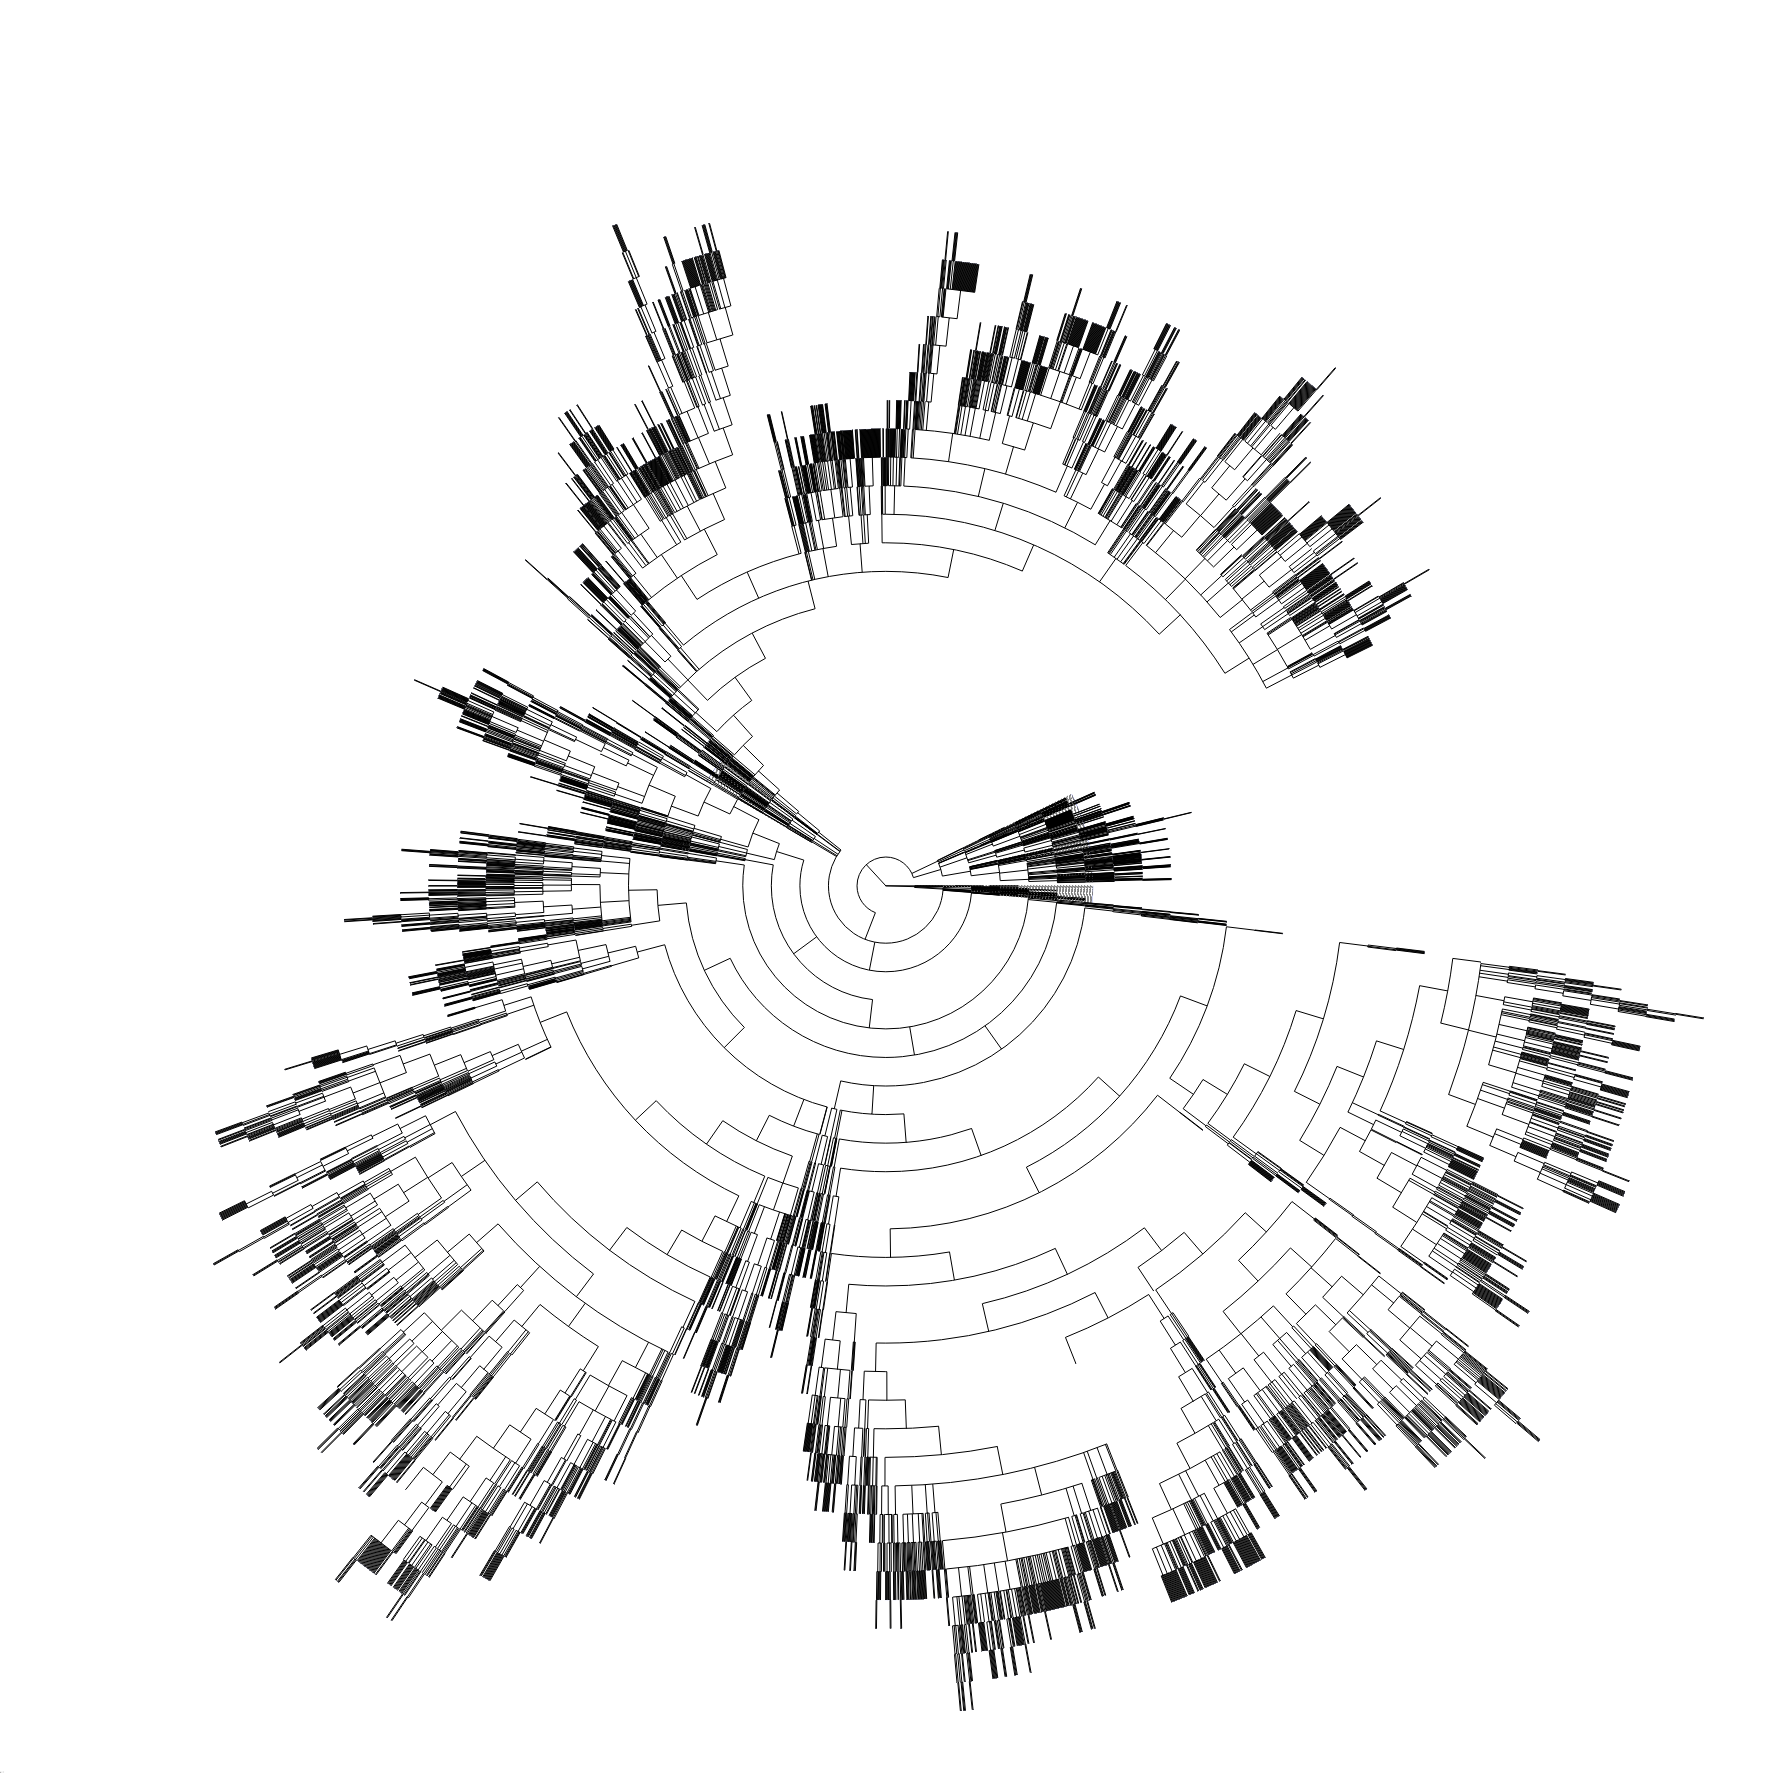

In [17]:
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)
# t.prune()
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False


# for node in t.traverse():
#     node_children = total_children(node)
#     if node_children >= 100:
#         size = 500 #min(500, 10 + node_children // 4)  # Cap size to 80
#         tf = TextFace(f"{node.name}", fsize=size)
#         tf.rotation = 90
#         node.add_face(tf, column=0, position="branch-right")
#         # # Calculate angle of node (ete3 provides node._angle in circular mode)
#         # if hasattr(node, "_angle"):
#         #     angle = node._angle
#         # else:
#         #     # fallback if not precomputed
#         #     continue

#         # # Rotate text to match radial layout
#         # tf.rotation = angle if angle < 180 else angle - 180
#         # tf.rotation = (tf.rotation + 90) % 360  # Adjust for upright readability

#     if node.name in set(interpro_species["Organism"]):
#         size = 20 #min(500, 10 + node_children // 4)  # Cap size to 80
#         tf = TextFace(f"{(str(node.name))[:3]}", fsize=size)
#         tf.rotation = 0
#         node.add_face(tf, column=0, position="branch-right")

t.render('%%inline', w=150, units='mm', tree_style=circular_style, dpi = 300)


In [19]:
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.arc_start = -180  # 0 degrees = 3 o'clock
circular_style.arc_span = 180
circular_style.scale = 100
#circular_style.branch_vertical_margin = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False
circular_style.show_leaf_name = False


for node in t.traverse():
    node_from_root = levels_from_root(node)
    node_children = total_children(node)
    if node_from_root < 2:# or node_children >= 200:
        print(node.name)
        size = 1000 #min(500, 10 + node_from_root // 4)  # Cap size to 80
        tf = TextFace(f"{node.name}", fsize = size)
        tf.rotation = 90
        node.add_face(tf, column=0, position="branch-top")

    nstyle = NodeStyle()
    nstyle['size'] = 0
    node.set_style(nstyle)


t.render('%%inline', w = 400, units='mm', tree_style=circular_style, dpi = 300)

root
unclassified sequences
Viruses
cellular organisms


In [175]:
node.up.name

'Bactrocera dorsalis complex'

In [50]:
import tqdm

In [151]:
# Saving to cache once
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)
total_children_in_data(t)

122144

In [152]:
total_children_in_data(t)

122144

In [154]:
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.mode = 'r'  # draw tree in circular mode
circular_style.scale = 100
circular_style.branch_vertical_margin = 3
circular_style.show_branch_length = False
circular_style.show_branch_support = False
circular_style.show_leaf_name = False


for node in tqdm.tqdm(t.traverse(), total=total_children(t), desc="Processing nodes"):
    node_from_root = levels_from_root(node)
    node_children = total_children(node)

    if node_children >= 300 or node_from_root < 3:
        if "vir" in node.name or "Viruses incertae" in node.name:
            print("Skipping labels for viruses:")
            print(node.name)
        if node.name != "root" and "vir" not in node.name and "Viruses incertae" not in node.name and node.name != "unclassified sequences" and node.name != "Sphinx1.76-related DNA" and "unidentified" not in node.name:
            size = 500 
            tf = TextFace(f"{str(node.name)} n={total_children_in_data(node)}", fsize=size)
            tf.rotation = 270
            tf.opacity = (total_children_in_data(node) + 25000)/100000
            node.add_face(tf, column=0, position="branch-right")

    # nstyle = NodeStyle()
    # nstyle['size'] = 10
    # node.set_style(nstyle)
    # if node.name in set(interpro_species["Organism"]):
    #     size = 20 #min(500, 10 + node_children // 4)  # Cap size to 80
    #     tf = TextFace(f"{(str(node.name))[:3]}", fsize=size)
    #     tf.rotation = 0
    #     node.add_face(tf, column=0, position="branch-right")

t.render('%%inline', w = 400, units='mm', tree_style=circular_style, dpi = 300)


Processing nodes: 8966it [00:28, 310.33it/s]                         


Skipping labels for viruses:
Captovirus AFV1
Skipping labels for viruses:
Alpharetrovirus
Skipping labels for viruses:
Inoviridae
Skipping labels for viruses:
Viruses incertae sedis
Skipping labels for viruses:
Heunggongvirae
Skipping labels for viruses:
Varidnaviria


In [155]:
# What are the viral sequences?

In [160]:
virus_proteins = seqs_with_codes.dropna()[seqs_with_codes.dropna()["species"].str.contains("virus")]
virus_proteins["DBD Family"].value_counts()

DBD Family
bZIP                15
CSD                 12
Forkhead            11
Homeodomain; POU     3
Homeodomain          1
SAND                 1
SMAD                 1
Name: count, dtype: int64

In [166]:
virus_proteins = seqs_with_codes.dropna()[seqs_with_codes.dropna()["species"].str.contains("virus")]
virus_proteins["Interpro superfamily name"].value_counts()

Interpro superfamily name
Basic-leucine zipper domain superfamily                  15
Nucleic acid-binding, OB-fol                             12
Winged helix-like DNA-binding domain superfamily         11
Lambda repressor-like, DNA-binding domain superfamily     3
Homedomain-like superfamily                               1
SAND-like domain superfamily                              1
SMAD/FHA domain superfamily                               1
Name: count, dtype: int64

In [165]:
seqs_with_codes.dropna()[seqs_with_codes.dropna()["species"].str.contains("virus")]

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,species,uniprot,ncbi,scores
435,../data/interpro_uniprot_downloads/IPR010982.f...,tr|Q37964|Q37964_9CAUD Repressor protein OS=Ra...,MKPEELVRHFGDVEKAAVGVGVTPGAVYQWLQAGEIPPLRQSDIEV...,protein,IPR010982,71,Homeodomain; POU,POU-specific domain,IPR000327,"Lambda repressor-like, DNA-binding domain supe...",Q37964_9CAUD Repressor protein OS=Ravinvirus N...,POU-specific,Q37964,Ravinvirus N15,Ravinvirus N15,Ravinvirus N15,100.000000
462,../data/interpro_uniprot_downloads/IPR010982.f...,tr|Q83VS7|Q83VS7_9CAUD C protein OS=Peduovirus...,MSNTISEKIVLMRKSEYLSRQQLADLTGVPYGTLSYYESGRSTPPT...,protein,IPR010982,99,Homeodomain; POU,POU-specific domain,IPR000327,"Lambda repressor-like, DNA-binding domain supe...",Q83VS7_9CAUD C protein OS=Peduovirus P2 OX=106...,POU-specific,Q83VS7,Peduovirus P2,Peduovirus P2,Peduovirus P2,100.000000
463,../data/interpro_uniprot_downloads/IPR010982.f...,tr|Q83VS9|Q83VS9_9CAUD Putative transcription ...,MIGKDRHTINHLLNHMAKRQPTIHDHRYRCLVQLLTKLRKEASLSQ...,protein,IPR010982,104,Homeodomain; POU,POU-specific domain,IPR000327,"Lambda repressor-like, DNA-binding domain supe...",Q83VS9_9CAUD Putative transcription factor OS=...,POU-specific,Q83VS9,Peduovirus P2,Peduovirus P2,Peduovirus P2,100.000000
1502,../data/interpro_uniprot_downloads/IPR009057.f...,sp|P01104|MYB_AVIMB Transforming protein Myb O...,NRTDVQCQHRWQKVLNPELNKGPWTKEEDQRVIEHVQKYGPKRWSD...,protein,IPR009057,382,Homeodomain,Homeodomain,IPR001356,Homedomain-like superfamily,MYB_AVIMB Transforming protein Myb OS=Avian my...,Homeodomain,P01104,Avian myeloblastosis virus,Avian myeloblastosis virus,Avian myeloblastosis virus,100.000000
5926,../data/interpro_uniprot_downloads/IPR036388.f...,sp|O09496|FIBER_BPK5 Tail spike protein OS=Esc...,MAKLTKPKTEGILHKGQSLYEYLDARVLTSKPFGAAGDATTDDTEV...,protein,IPR036388,632,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,FIBER_BPK5 Tail spike protein OS=Escherichia v...,Fork head,O09496,Escherichia virus K5,Escherichia virus K5,Escherichia virus K5,100.000000
6591,../data/interpro_uniprot_downloads/IPR036388.f...,sp|P33863|PG065_VAR67 RNA-binding protein OPG0...,MSKIYIDERSDAEIVCEAIKNIGLEGVTAVQLTRQLNMEKREVNKA...,protein,IPR036388,190,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,PG065_VAR67 RNA-binding protein OPG065 OS=Vari...,Fork head,P33863,Variola virus,Variola virus,Variola virus,100.000000
6804,../data/interpro_uniprot_downloads/IPR036388.f...,sp|Q9DHS8|E3_YLDV Protein E3 homolog OS=Yaba-l...,MDLLSCTVNDAEIFSLVKKEVLSLNTNDYTTAISLSNRLKINKKKI...,protein,IPR036388,185,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,E3_YLDV Protein E3 homolog OS=Yaba-like diseas...,Fork head,Q9DHS8,Yaba-like disease virus,Yaba-like disease virus,Yaba-like disease virus,100.000000
8476,../data/interpro_uniprot_downloads/IPR036388.f...,tr|A2I306|A2I306_9CAUD Transcriptional regulat...,MSISEGDDAYIRSLIHFFGNQPDPWGIKDTKSVFIYANQPFRELVG...,protein,IPR036388,235,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,A2I306_9CAUD Transcriptional regulator OS=Hapu...,Fork head,A2I306,Hapunavirus VP882,Hapunavirus VP882,Hapunavirus VP882,100.000000
8481,../data/interpro_uniprot_downloads/IPR036388.f...,tr|A4FTK7|A4FTK7_9VIRU Uncharacterized protein...,MASDTNGTGTSNGTYLTLRKKKSEPKSVTFNLADDGARVVTARGTS...,protein,IPR036388,278,Forkhead,Fork head domain,IPR001766,Winged helix-like DNA-binding domain superfamily,A4FTK7_9VIRU Uncharacterized protein OS=Cyprin...,Fork head,A4FTK7,Cyprinid herpesvirus 3,Cyprinid herpesvirus 3,Cyprinid herpesvirus 3,100.000000
8917,../data/interpro_uniprot_downloads/IPR036388.f...,tr|Q6Q0J9|Q6Q0J9_9VIRU PadR family transcripti...,MKIRKYMRINYYIILKVLVINGSRLEKKRLRSEILKRFDIDISDGV...,protein,IPR036388,93,Forkhead,Fork hea

In [58]:
seqs_with_codes["species"].drop_duplicates()

0         Drosophila melanogaster
2          Caenorhabditis elegans
3                    Homo sapiens
7                    Mus musculus
9         Caenorhabditis briggsae
                   ...           
334650       Leishmania enriettii
334675         Syntrichia ruralis
334707     Chlamydomonas sp. HS-5
334913          Durinskia baltica
334935          Tisochrysis lutea
Name: species, Length: 6282, dtype: object

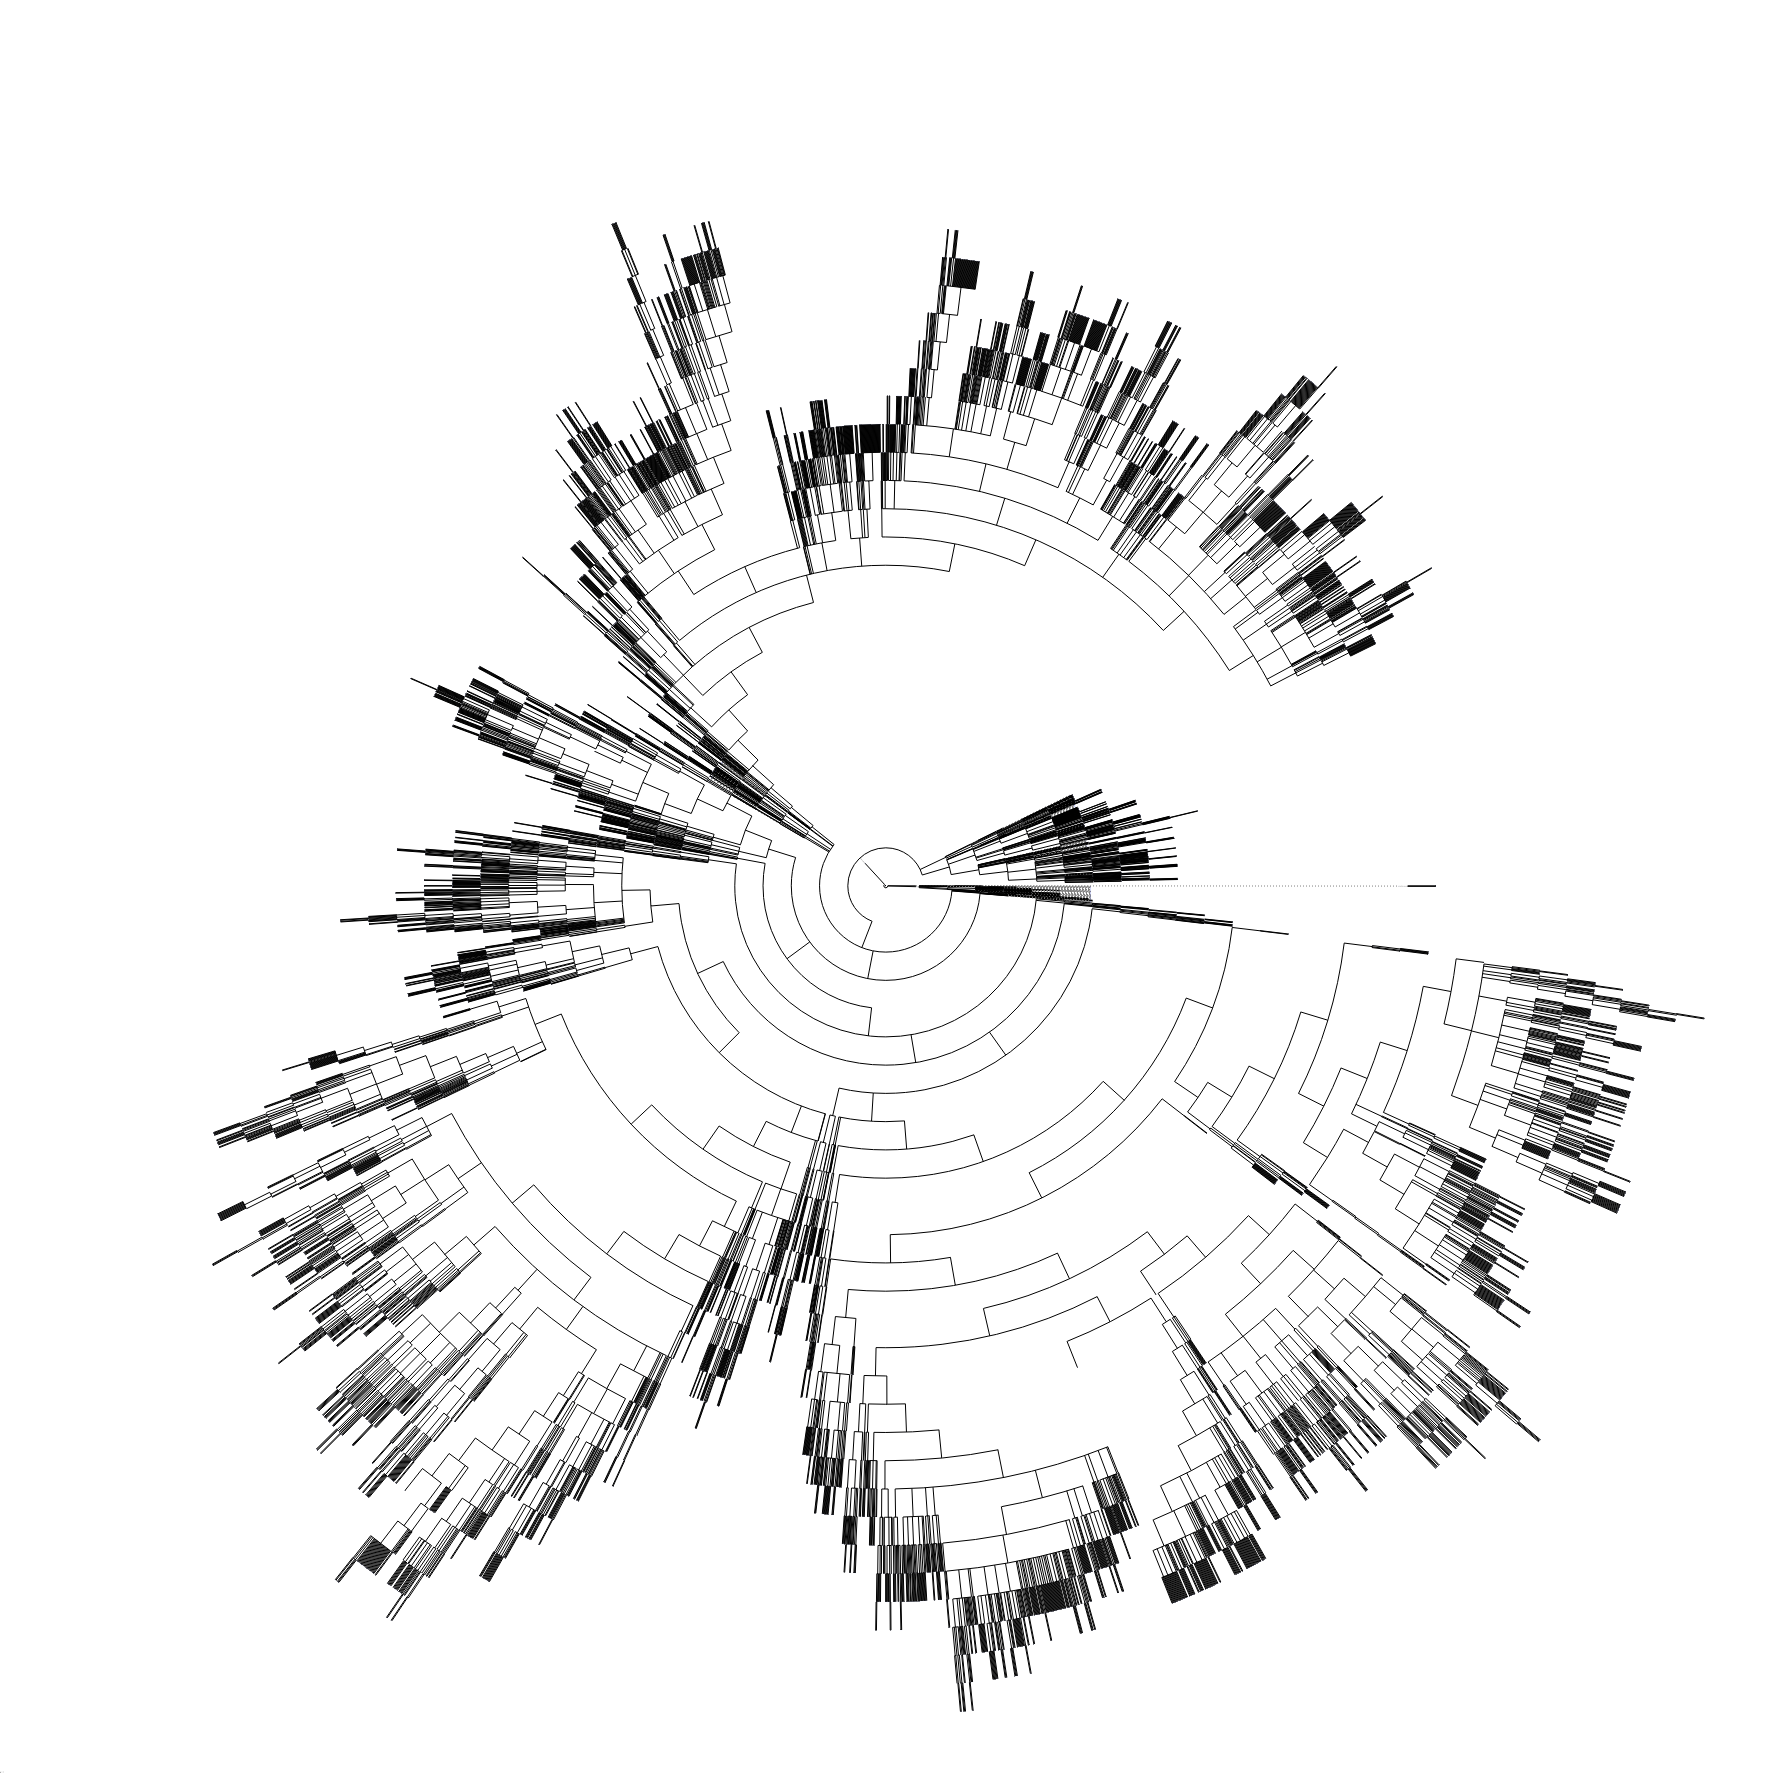

In [ ]:
t = Tree(open("../data/training_data_phylip_tree_more_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False

for node in t.traverse():
    i += 1
    node_from_root = levels_from_root(node)
    node_children = total_children(node)
    if node_from_root < 2:# or node_children >= 200:
        size = 12 #min(500, 10 + node_from_root // 4)  # Cap size to 80
        tf = TextFace(f"{node.name}", fsize=size)
        tf.rotation = 0
        node.add_face(tf, column=0, position="branch-right")

    nstyle = NodeStyle()
    nstyle['size'] = 0
    node.set_style(nstyle)

t.render('%%inline', w=150, units='mm', tree_style=circular_style, dpi = 300)


In [49]:
i

8966

In [133]:
interpro_species["Organism"].unique()

array(['Xenopus tropicalis', 'Gallus gallus', 'Xenopus laevis',
       'Rattus norvegicus', 'Bos taurus', 'Homo sapiens',
       'Caenorhabditis elegans', 'Mus musculus',
       'Drosophila melanogaster', 'Danio rerio', 'Dugesia japonica',
       'Ovis aries', 'Sus scrofa', 'Meleagris gallopavo',
       'Oncorhynchus mykiss', 'Bombyx mori', 'Drosophila virilis',
       'Macaca mulatta', 'Mesocricetus auratus', 'Oncorhynchus keta',
       'Canis lupus familiaris', 'Solanum lycopersicum',
       'Oryza sativa subsp. japonica', 'Psilocybe cyanescens',
       'Actinidia chinensis var. chinensis', 'Equus caballus',
       'Arabidopsis thaliana', 'Aspergillus fumigatus', 'Lotus japonicus',
       'Oryctolagus cuniculus', 'Schizosaccharomyces pombe',
       'Branchiostoma belcheri', 'Saccharomyces cerevisiae', 'Zea mays',
       'Coturnix japonica', 'Marmota monax', 'Kluyveromyces lactis',
       'Lytechinus variegatus', 'Strongylocentrotus purpuratus',
       'Xenopus borealis', 'Bos mutus g

In [ ]:
interpro_species[]

,uniprotID,Organism
1,A1L0Z1,Xenopus tropicalis
2,A7Y7W2,Gallus gallus
3,B3DM23,Xenopus tropicalis
4,B3DM25,Xenopus tropicalis
5,B7ZQA9,Xenopus laevis
...,...,...
12777,Q9Y2D1,Homo sapiens
12778,Q9Y4A8,Homo sapiens
12779,Q9Y5Q3,Homo sapiens
12780,Q9Z125,Mus musculus


In [135]:
# Returns average of all leaves' occurence counts
def average_leaf_count(node):
    if node.is_leaf:
        if node.name in count_dict.keys():
            return count_dict[node.name]
        else:
            return 0
    else:
        leaf_counts = [average_leaf_count(leaf) for leaf in node.get_children()]
        return np.average(leaf_counts)



In [142]:
pd.merge(seqs_with_codes, interpro_species, on = "uniprotID", how = 'left')

,path,id,seq,evidence,Interpro superfamily domain code,len,DBD Family,Interpro domain name,Interpro domain code,Interpro superfamily name,name,Interpro domain name shortened,uniprotID,Organism
0,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,479,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K6B8_DROME Modifier of mdg4, isoform AE ...","Zinc finger, FLYWCH-type",A0A0B4K6B8,NaN
1,../data/interpro_uniprot_downloads/IPR007588.f...,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,510,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,"A0A0B4K7A6_DROME Modifier of mdg4, isoform AD ...","Zinc finger, FLYWCH-type",A0A0B4K7A6,NaN
2,../data/interpro_uniprot_downloads/IPR007588.f...,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,protein,IPR007588,443,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FPEB1_CAEEL FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",A0A5S9MMK5,Caenorhabditis elegans
3,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,protein,IPR007588,716,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,FWCH1_HUMAN FLYWCH-type zinc finger-containing...,"Zinc finger, FLYWCH-type",Q4VC44,Homo sapiens
4,../data/interpro_uniprot_downloads/IPR007588.f...,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,protein,IPR007588,610,FLYWCH,"Zinc finger, FLYWCH-type",IPR007588,NaN,MMD4_DROME Modifier of mdg4 OS=Drosophila mela...,"Zinc finger, FLYWCH-type",Q86B87,Drosophila melanogaster
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135201,../data/interpro_uniprot_downloads/transcript_...,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,transcript,IPR012340,300,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8C846_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8C846,NaN
135202,../data/interpro_uniprot_downloads/transcript_...,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,transcript,IPR012340,939,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8CA25_CERCA (Mediterranean fruit fly) hypothe...,Cold-shock,W8CA25,NaN
135203,../data/interpro_uniprot_downloads/transcript_...,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,transcript,IPR012340,294,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",W8QUS6_MIMNO Cold shock domain protein OS=Mima...,Cold-shock,W8QUS6,NaN
135204,../data/interpro_uniprot_downloads/transcript_...,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,transcript,IPR012340,329,CSD,Cold-shock domain,IPR011129,"Nucleic acid-binding, OB-fol",X5CQH7_9EUKA 30S plastidal ribosomal protein S...,Cold-shock,X5CQH7,NaN


In [136]:
# calculate minimum and maximum to use for color map
max_count = - 1 * np.inf
min_count = np.inf

for node in t:
    avg_color = average_leaf_count(node)
    max_count = max(max_count, avg_color)
    min_count = min(min_count, avg_color)

print(min_count)
print(max_count)

NameError: name 'count_dict' is not defined